

**Stablecoin Liquidity Rotation Dashboard** 

Over the last 7 days, Ethereum remained the dominant stablecoin settlement layer by volume, while net flow analysis revealed where liquidity was expanding versus contracting. USDC accounted for the majority of tracked activity, with capital flows concentrated across a small number of chains.

In [28]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')


#Load the data
df = pd.read_csv('stablecoin_flows.csv')
df['day'] = pd.to_datetime(df['day'])

**Data cleaning**

In [30]:
df.columns.tolist()

['day',
 'blockchain',
 'token_symbol',
 'mint_volume',
 'burn_volume',
 'total_volume']

In [31]:
df['total_volume'] = df['total_volume'].fillna(0)

In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   day           32 non-null     datetime64[ns, UTC]
 1   blockchain    32 non-null     object             
 2   token_symbol  32 non-null     object             
 3   mint_volume   32 non-null     float64            
 4   burn_volume   32 non-null     float64            
 5   total_volume  32 non-null     object             
dtypes: datetime64[ns, UTC](1), float64(2), object(3)
memory usage: 1.6+ KB


In [33]:
df.head(5)

,day,blockchain,token_symbol,mint_volume,burn_volume,total_volume
0,2026-06-25 00:00:00+00:00,arbitrum,USDC,0.000000e+00,0.000000e+00,<nil>
1,2026-06-25 00:00:00+00:00,ethereum,USDC,0.000000e+00,0.000000e+00,<nil>
2,2026-06-25 00:00:00+00:00,ethereum,USDT,0.000000e+00,0.000000e+00,<nil>
3,2026-06-25 00:00:00+00:00,polygon,USDC,0.000000e+00,0.000000e+00,<nil>
4,2026-06-24 00:00:00+00:00,arbitrum,USDC,2.681655e+08,2.644557e+08,2.359159153945614e+09


In [72]:
# Validation checks

df['net_flow'] = df['mint_volume'] - df['burn_volume']
df['total_volume'] = pd.to_numeric(df['total_volume'], errors='coerce')
df['net_flow'] = pd.to_numeric(df['net_flow'], errors='coerce')
chain_volume = df.groupby('blockchain')['total_volume'].sum().sort_values(ascending=False)
cutoff_date = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=7)
df = df[df['day'] >= cutoff_date]

df['total_volume'] = pd.to_numeric(df['total_volume'], errors='coerce').fillna(0)
df['net_flow'] = pd.to_numeric(df['net_flow'], errors='coerce').fillna(0)

chain_volume = df.groupby('blockchain')['total_volume'].sum().sort_values(ascending=False)

token_by_chain = df.groupby(['blockchain', 'token_symbol'])['total_volume'].sum().unstack().fillna(0)

daily_pivot = df.pivot_table(index='day', columns='blockchain', values='total_volume', aggfunc='sum').fillna(0)

net_flow_by_chain = df.groupby('blockchain')['net_flow'].sum()

In [35]:
 # Executive Summary
total_volume = df['total_volume'].sum()

top_chain_volume = (
    df.groupby('blockchain')['total_volume']
      .sum()
      .sort_values(ascending=False)
)

top_chain = top_chain_volume.index[0]

top_chain_share = (
    top_chain_volume.iloc[0] /
    top_chain_volume.sum()
) * 100

top_token = (
    df.groupby('token_symbol')['total_volume']
      .sum()
      .idxmax()
)

total_net_flow = df['net_flow'].sum()

print("="*60)
print("EXECUTIVE SUMMARY")
print("="*60)

print(
    f"Total stablecoin volume reached ${total_volume/1e9:.2f}B "
    f"across tracked chains."
)

print(
    f"{top_chain.title()} dominated activity, accounting for "
    f"{top_chain_share:.1f}% of total volume."
)

print(
    f"{top_token} remained the leading stablecoin by usage."
)

print(
    f"Aggregate net flow was ${total_net_flow/1e6:.2f}M."
)

EXECUTIVE SUMMARY
Total stablecoin volume reached $397.31B across tracked chains.
Ethereum dominated activity, accounting for 93.4% of total volume.
USDC remained the leading stablecoin by usage.
Aggregate net flow was $-774.28M.


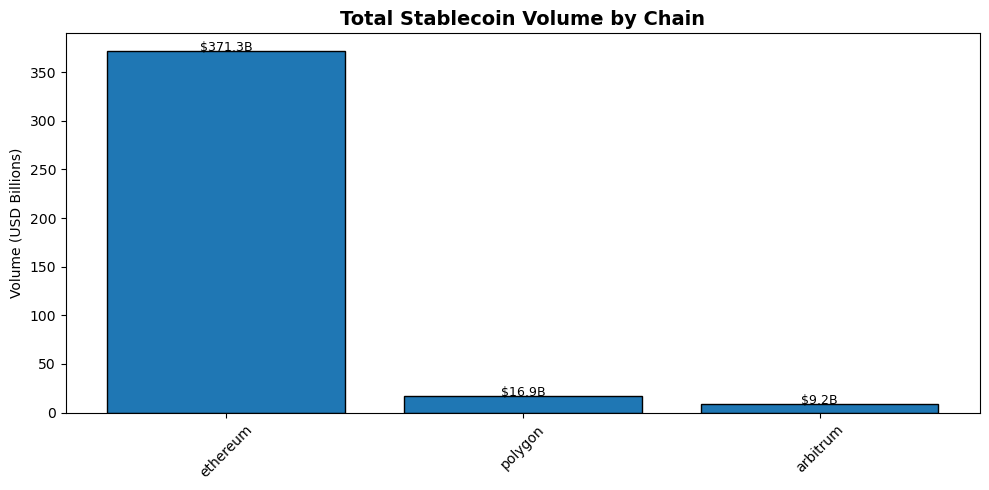

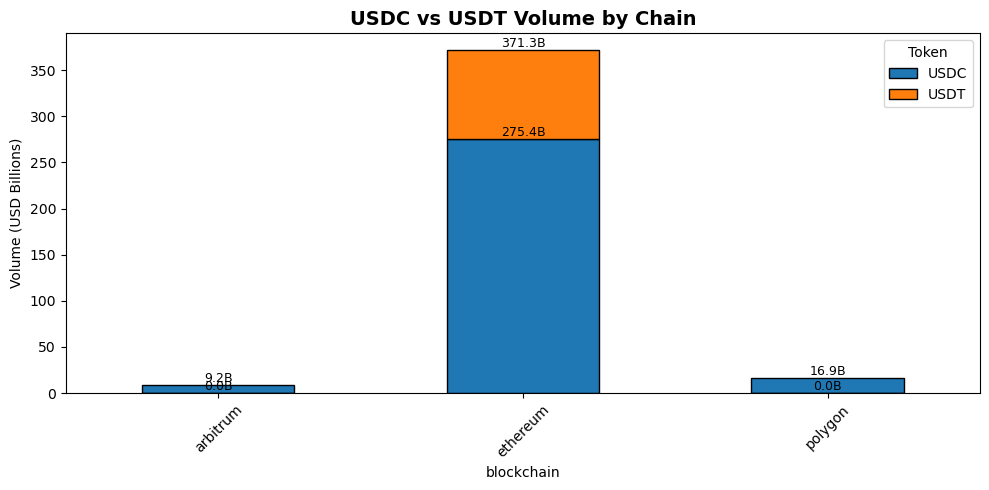

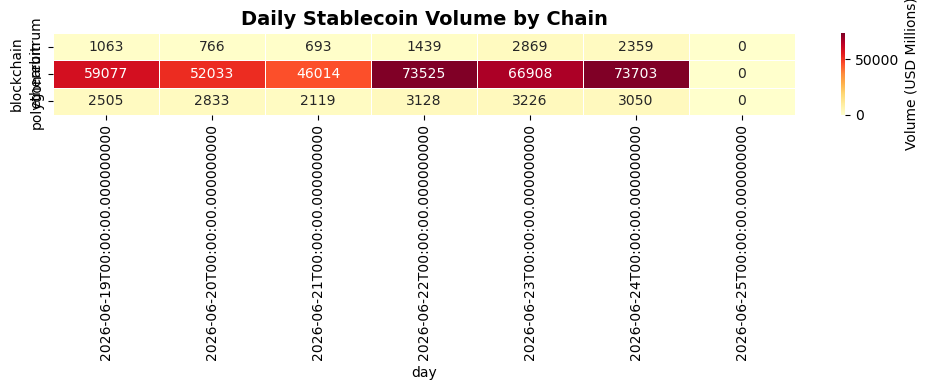

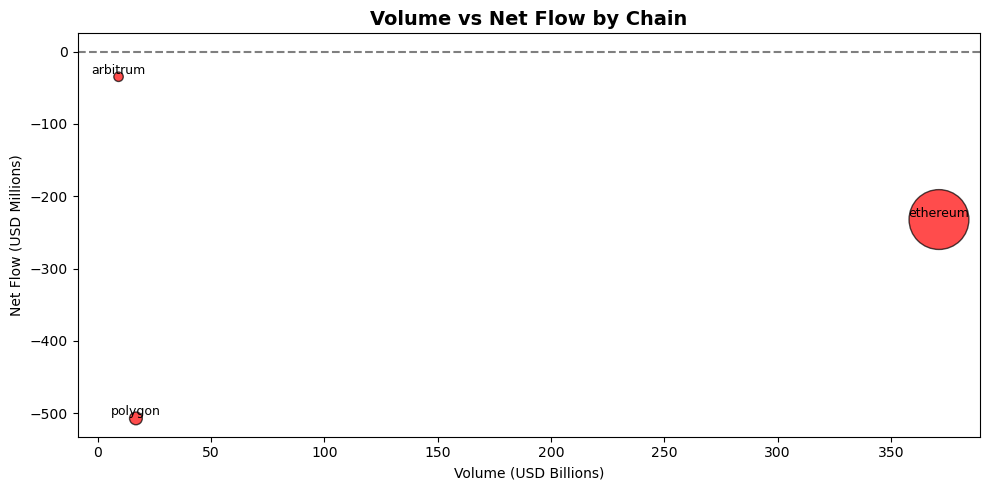

In [70]:

#  Visualizations


# ---------- VISUAL 1: Total Volume by Chain ----------

plt.figure(figsize=(10, 5))
bars = plt.bar(chain_volume.index, chain_volume.values / 1e9, color='#1f77b4', edgecolor='black')
plt.title('Total Stablecoin Volume by Chain', fontsize=14, fontweight='bold')
plt.ylabel('Volume (USD Billions)')
plt.xticks(rotation=45)
for bar, val in zip(bars, chain_volume.values / 1e9):
    if val > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'${val:.1f}B', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('visual_1_volume_by_chain.png', dpi=200)
plt.show()

# ---------- VISUAL 2: USDC vs USDT by Chain ----------

fig, ax = plt.subplots(figsize=(10, 5))
token_by_chain_bn = token_by_chain / 1e9
token_by_chain_bn.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
ax.set_title('USDC vs USDT Volume by Chain', fontsize=14, fontweight='bold')
ax.set_ylabel('Volume (USD Billions)')
ax.legend(title='Token')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fB', fontsize=9)
plt.tight_layout()
plt.savefig('visual_2_usdc_vs_usdt.png', dpi=200)
plt.show()

# ---------- VISUAL 3: Daily Volume Heatmap ----------

if not daily_pivot.empty and daily_pivot.values.sum() > 0:
    daily_pivot_millions = daily_pivot / 1e6
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(daily_pivot_millions.T, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5,
                cbar_kws={'label': 'Volume (USD Millions)'}, ax=ax)
    ax.set_title('Daily Stablecoin Volume by Chain', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('visual_3_heatmap.png', dpi=200)
    plt.show()
else:
    print(" Heatmap skipped: No daily data available")

# ---------- VISUAL 4: Volume vs Net Flow ----------

plt.figure(figsize=(10, 5))
colors = ['green' if flow > 0 else 'red' for flow in net_flow_by_chain]
sizes = chain_volume / 1e9
plt.scatter(chain_volume / 1e9, net_flow_by_chain / 1e6, s=sizes*5, color=colors, alpha=0.7, edgecolors='black')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Volume vs Net Flow by Chain', fontsize=14, fontweight='bold')
plt.xlabel('Volume (USD Billions)')
plt.ylabel('Net Flow (USD Millions)')
for chain, vol, flow in zip(chain_volume.index, chain_volume.values / 1e9, net_flow_by_chain.values / 1e6):
    plt.text(vol, flow, chain, fontsize=9, ha='center', va='bottom')
plt.tight_layout()
plt.savefig('visual_4_bubble.png', dpi=200)
plt.show()

In [37]:

# KPI: Total Volume, Net Flow, Top Chain, Top Stablecoin


# 1. Total Volume (all chains combined)
total_volume_all = df['total_volume'].sum()

# 2. Net Flow (mint - burn across all chains)
total_net_flow = df['net_flow'].sum()

# 3. Top Chain (by total volume)
chain_volume = df.groupby('blockchain')['total_volume'].sum()
top_chain = chain_volume.idxmax()
top_chain_volume = chain_volume.max()

# 4. Top Stablecoin (by total volume across all chains)
token_volume = df.groupby('token_symbol')['total_volume'].sum()
top_token = token_volume.idxmax()
top_token_volume = token_volume.max()

# ==========================================
# Print KPI table
# ==========================================
print("=" * 50)
print(" KPI SUMMARY")
print("=" * 50)
print(f"Total Volume (all chains):  ${total_volume_all:,.2f}")
print(f"Net Flow (mint - burn):     ${total_net_flow:,.2f}")
print(f"Top Chain:                 {top_chain} (${top_chain_volume:,.2f})")
print(f"Top Stablecoin:            {top_token} (${top_token_volume:,.2f})")
print("=" * 50)

 KPI SUMMARY
Total Volume (all chains):  $397,311,104,772.94
Net Flow (mint - burn):     $-774,279,407.57
Top Chain:                 ethereum ($371,261,156,943.97)
Top Stablecoin:            USDC ($301,492,638,773.03)


**INSIGHTS**

In [39]:
top_chain = chain_volume.idxmax()

chain_share = (
    chain_volume.max() /
    chain_volume.sum()
) * 100

top_netflow_chain = (
    df.groupby('blockchain')['net_flow']
      .sum()
      .idxmax()
)

print("\nKEY FINDINGS")
print("-"*50)

print(
    f"{top_chain} processed "
    f"{chain_share:.1f}% of all stablecoin volume."
)

print(
    f"{top_netflow_chain} recorded the strongest "
    f"net inflows during the period."
)


KEY FINDINGS
--------------------------------------------------
ethereum processed 93.4% of all stablecoin volume.
polygon recorded the strongest net inflows during the period.


In [40]:
flow = (
    df.groupby('blockchain')
      .agg({
          'mint_volume':'sum',
          'burn_volume':'sum'
      })
)

flow['mint_burn_ratio'] = (
    flow['mint_volume'] /
    flow['burn_volume']
)

flow.sort_values(
    'mint_burn_ratio',
    ascending=False
)

,mint_volume,burn_volume,mint_burn_ratio
blockchain,,,
polygon,6.276577e+08,6.623783e+08,0.947582
ethereum,2.992511e+09,3.499838e+09,0.855043
arbitrum,8.264189e+08,1.058651e+09,0.780634


In [41]:
chain_volume = (
    df.groupby('blockchain')['total_volume']
      .sum()
      .sort_values(ascending=False)
)

print("\nLIQUIDITY CONCENTRATION")
print("-"*50)

for chain, vol in chain_volume.items():
    share = (vol / chain_volume.sum()) * 100

    print(
        f"{chain.title():<12} "
        f"${vol/1e9:>6.2f}B "
        f"({share:.1f}%)"
    )


LIQUIDITY CONCENTRATION
--------------------------------------------------
Ethereum     $371.26B (93.4%)
Polygon      $ 16.86B (4.2%)
Arbitrum     $  9.19B (2.3%)


In [42]:
net_flow_chain = (
    df.groupby('blockchain')['net_flow']
      .sum()
      .sort_values(ascending=False)
)

print("\nCAPITAL ROTATION")
print("-"*50)

for chain, flow in net_flow_chain.items():

    direction = "Inflow" if flow > 0 else "Outflow"

    print(
        f"{chain.title():<12} "
        f"{direction:<10} "
        f"${flow/1e6:.2f}M"
    )


CAPITAL ROTATION
--------------------------------------------------
Polygon      Outflow    $-34.72M
Arbitrum     Outflow    $-232.23M
Ethereum     Outflow    $-507.33M


In [43]:
token_share = (
    df.groupby('token_symbol')['total_volume']
      .sum()
)

token_share = (
    token_share /
    token_share.sum()
) * 100

print("\nSTABLECOIN MARKET SHARE")
print("-"*50)

for token, share in token_share.items():
    print(f"{token}: {share:.1f}%")


STABLECOIN MARKET SHARE
--------------------------------------------------
USDC: 75.9%
USDT: 24.1%


In [44]:
efficiency = (
    df.groupby('blockchain')
      .agg({
          'mint_volume':'sum',
          'burn_volume':'sum'
      })
)

efficiency['mint_burn_ratio'] = (
    efficiency['mint_volume']
    /
    efficiency['burn_volume']
)

efficiency = efficiency.sort_values(
    'mint_burn_ratio',
    ascending=False
)

efficiency

,mint_volume,burn_volume,mint_burn_ratio
blockchain,,,
polygon,6.276577e+08,6.623783e+08,0.947582
ethereum,2.992511e+09,3.499838e+09,0.855043
arbitrum,8.264189e+08,1.058651e+09,0.780634


In [45]:
largest_inflow_chain = net_flow_chain.idxmax()

largest_outflow_chain = net_flow_chain.idxmin()

print("\nKEY FINDINGS")
print("="*60)

print(
    f"1. {top_chain.title()} accounted for "
    f"{top_chain_share:.1f}% of total stablecoin volume."
)

print(
    f"2. {largest_inflow_chain.title()} recorded "
    f"the strongest net capital inflows."
)

print(
    f"3. {largest_outflow_chain.title()} experienced "
    f"the largest net capital outflows."
)

print(
    f"4. {top_token} remained the dominant "
    f"stablecoin across the ecosystem."
)

print(
    "5. Liquidity activity was concentrated in a small "
    "number of chains, highlighting ecosystem dependence."
)


KEY FINDINGS
1. Ethereum accounted for 93.4% of total stablecoin volume.
2. Polygon recorded the strongest net capital inflows.
3. Ethereum experienced the largest net capital outflows.
4. USDC remained the dominant stablecoin across the ecosystem.
5. Liquidity activity was concentrated in a small number of chains, highlighting ecosystem dependence.


# Conclusions
Ethereum remained the dominant liquidity hub.
USDC accounted for the majority of tracked activity.
Net inflows suggest capital accumulated on X chain.
Liquidity remains concentrated across a limited number of ecosystems.

# Recommendation
Monitoring net flow trends may provide earlier signals of liquidity migration than volume metrics alone.

In [48]:
plt.savefig(
    "stablecoin_liquidity_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>